<center><h1> Анализ музыкальных трендов и прогнозирование </h1></center>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

## Данные 

In [4]:
data = pd.read_csv("../../data/spotify_data.csv", index_col=0)

In [5]:
AUDIO_FEATURES = [
    'danceability', 'energy', 'valence',
    'acousticness', 'instrumentalness',
    'speechiness', 'loudness', 'tempo'
]
data[AUDIO_FEATURES].describe().round(3)

,danceability,energy,valence,acousticness,instrumentalness,speechiness,loudness,tempo
count,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000,1159764.000
mean,0.537,0.640,0.456,0.322,0.252,0.093,-8.981,121.377
std,0.184,0.271,0.269,0.355,0.365,0.127,5.682,29.780
min,0.000,0.000,0.000,0.000,0.000,0.000,-58.100,0.000
25%,0.413,0.454,0.226,0.006,0.000,0.037,-10.829,98.797
50%,0.550,0.694,0.438,0.147,0.002,0.051,-7.450,121.931
75%,0.677,0.873,0.674,0.640,0.614,0.089,-5.276,139.903
max,0.993,1.000,1.000,0.996,1.000,0.971,6.172,249.993


## Анализ врем. рядов 

Агрегируем медиану каждого признака по году — медиана устойчивее к выбросам чем среднееф

In [6]:
yearly = data.groupby('year')[AUDIO_FEATURES + ['popularity']].median().reset_index()
yearly.tail(5)

,year,danceability,energy,valence,acousticness,instrumentalness,speechiness,loudness,tempo,popularity
19,2019,0.566,0.703,0.400,0.138,0.00133,0.0527,-7.157,122.0430,25.0
20,2020,0.569,0.684,0.398,0.149,0.00153,0.0525,-7.334,122.0150,26.0
21,2021,0.566,0.691,0.400,0.146,0.00115,0.0515,-7.290,122.0615,28.0
22,2022,0.564,0.702,0.401,0.143,0.00133,0.0521,-7.185,123.0020,31.0
23,2023,0.556,0.677,0.394,0.174,0.00437,0.0513,-7.690,123.0030,17.0


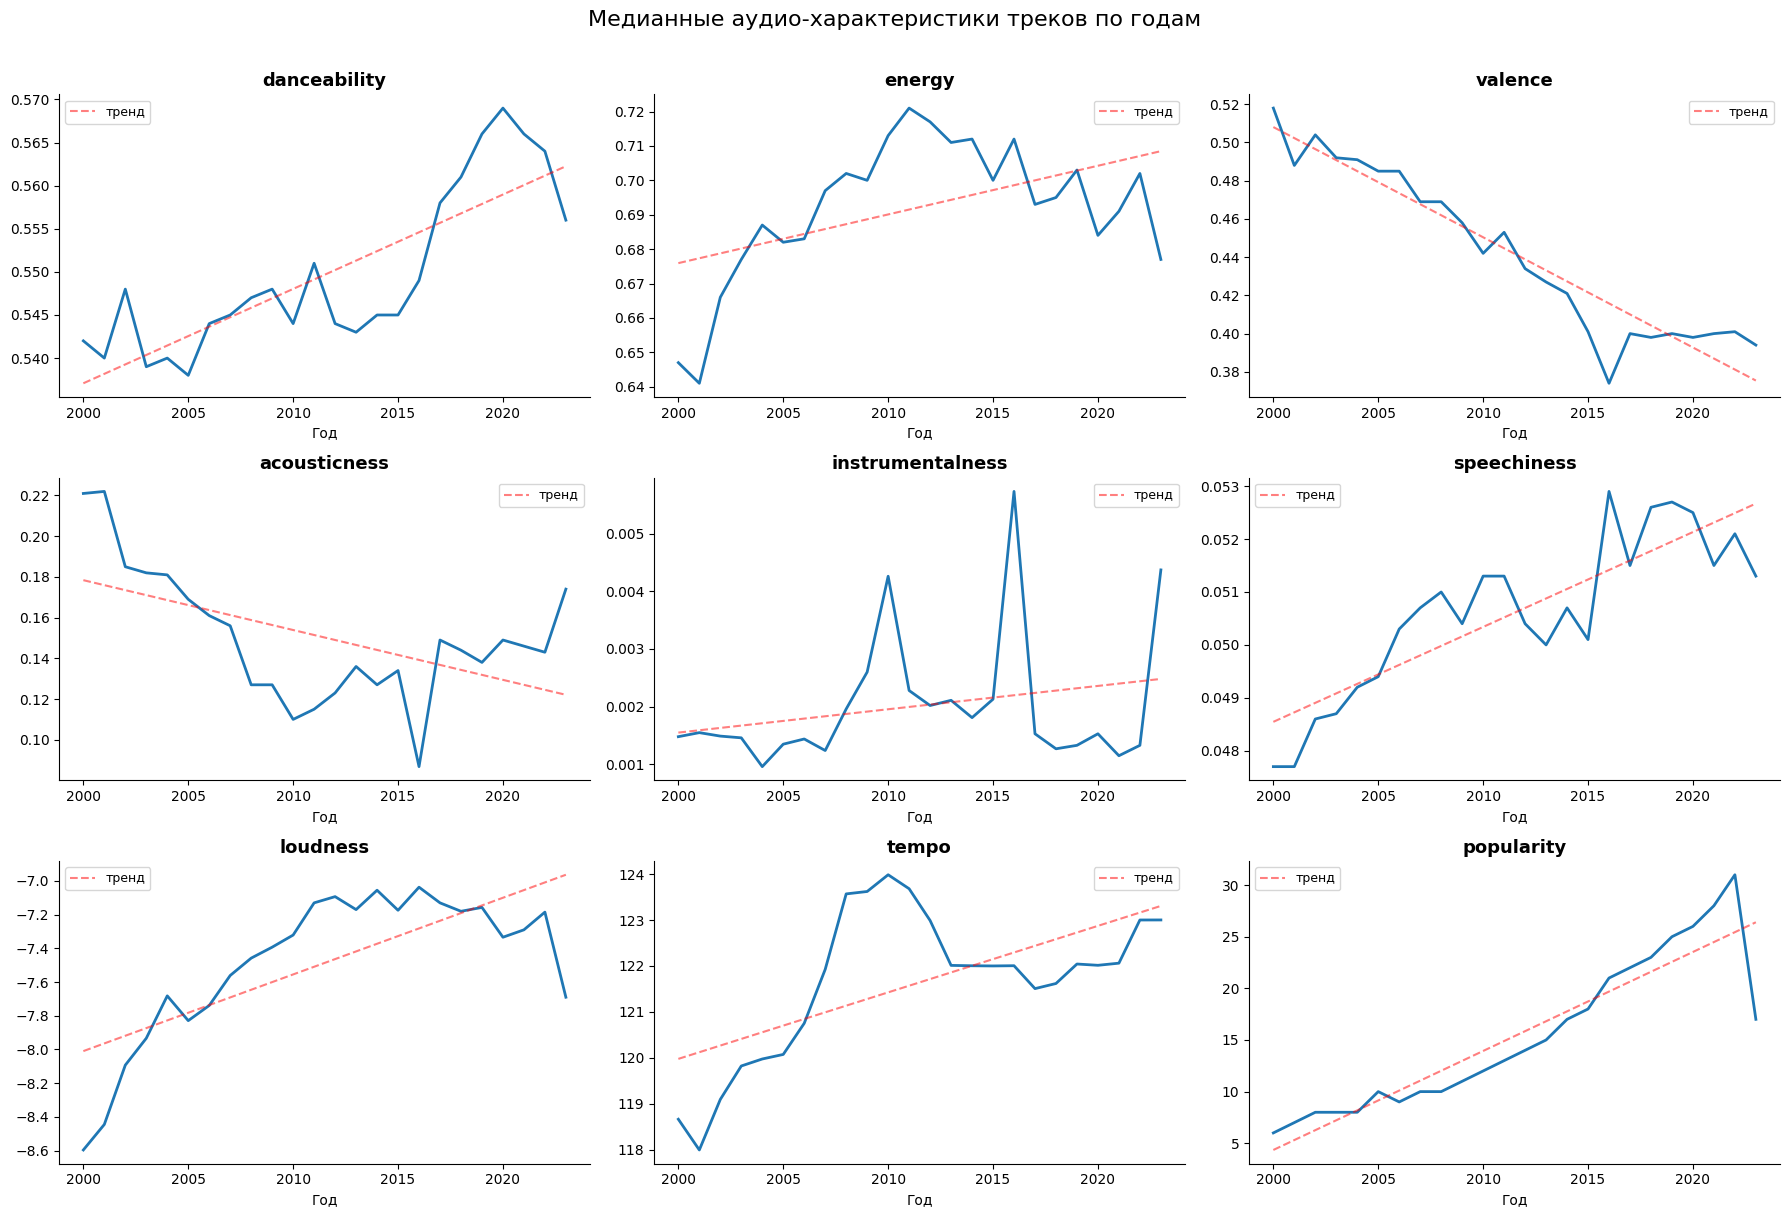

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

features_to_plot = AUDIO_FEATURES + ['popularity']

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    ax.plot(yearly['year'], yearly[feat], linewidth=2)
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel('Год')
    # Линия тренда
    z = np.polyfit(yearly['year'], yearly[feat], 1)
    p = np.poly1d(z)
    ax.plot(yearly['year'], p(yearly['year']), '--', alpha=0.5, color='red', label=f'тренд')
    ax.legend(fontsize=9)

# Убираем лишний subplot
for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Медианные аудио-характеристики треков по годам', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('audio_trends.png', dpi=150, bbox_inches='tight')
plt.show()

Жанры 

In [8]:
top_genres = data['genre'].value_counts().head(8).index.tolist()
print('Топ жанры:', top_genres)

genre_year = (
    data[data['genre'].isin(top_genres)]
    .groupby(['year', 'genre'])['popularity']
    .median()
    .reset_index()
)

Топ жанры: ['black-metal', 'gospel', 'ambient', 'acoustic', 'alt-rock', 'emo', 'indian', 'k-pop']


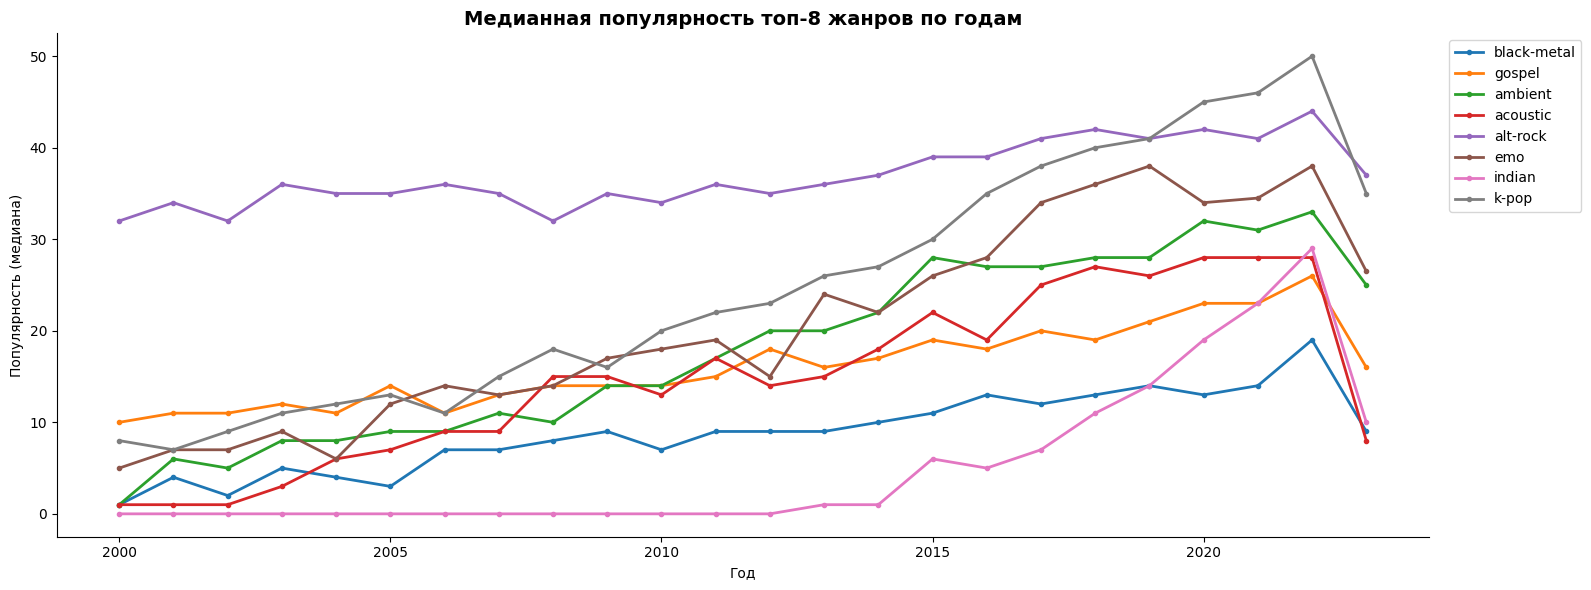

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))

for genre in top_genres:
    data_temp = genre_year[genre_year['genre'] == genre]
    ax.plot(
        data_temp['year'], data_temp['popularity'],
        linewidth=2, label=genre, marker='o', markersize=3
    )
ax.set_title('Медианная популярность топ-8 жанров по годам', fontsize=14, fontweight='bold')
ax.set_xlabel('Год')
ax.set_ylabel('Популярность (медиана)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('genre_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

Изменение характеристик по десятилетиям

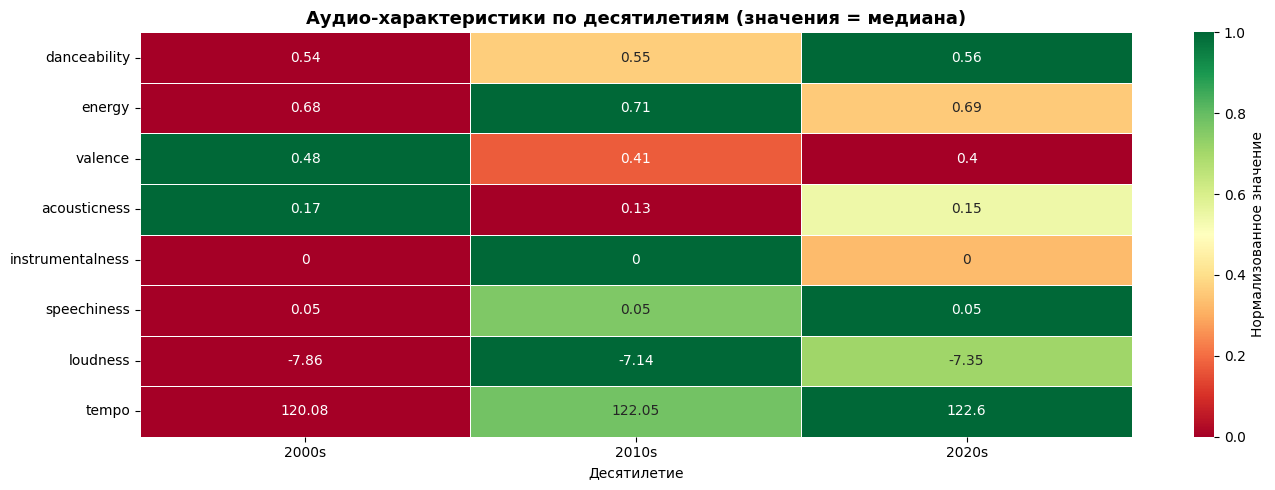

In [10]:
data['decade'] = (data['year'] // 10 * 10).astype(str) + 's'

decade_features = (
    data.groupby('decade')[AUDIO_FEATURES]
    .median()
)

# Нормализуем каждый признак от 0 до 1 для сравнимости
decade_norm = ( 
    (decade_features - decade_features.min())
        / (decade_features.max() - decade_features.min())
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    decade_norm.T,
    annot=decade_features.T.round(2),
    fmt='g',
    cmap='RdYlGn',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Нормализованное значение'}
)
ax.set_title('Аудио-характеристики по десятилетиям (значения = медиана)', fontsize=13, fontweight='bold')
ax.set_xlabel('Десятилетие')
plt.tight_layout()
plt.savefig('decade_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Прогнозирование временных рядов

- **Linear Regression** — baseline, линейный тренд
- **Exponential Smoothing (Holt)** — учитывает тренд
- **SARIMAX** — учитывает авторегрессию и скользящее среднее

In [11]:
FORECAST_YEARS = 5   # сколько лет прогнозируем вперёд
FEATURES_TO_FORECAST = ['danceability', 'energy', 'valence', 'acousticness']

def forecast_feature(series: pd.Series, n_forecast: int = 5) -> dict:
    """
    Строит прогноз тремя методами.
    series — временной ряд с индексом = год.
    Возвращает словарь с прогнозами.
    """
    years = series.index.values
    values = series.values
    future_years = np.arange(years[-1] + 1, years[-1] + n_forecast + 1)
    
    results = {'future_years': future_years}
    
    # --- 1. Linear Regression (baseline) ---
    lr = LinearRegression()
    lr.fit(years.reshape(-1, 1), values)
    results['linear'] = lr.predict(future_years.reshape(-1, 1))
    
    # --- 2. Exponential Smoothing (Holt — trend без сезонности) ---
    try:
        es_model = ExponentialSmoothing(values, trend='add', seasonal=None)
        es_fit = es_model.fit(optimized=True)
        results['exp_smoothing'] = es_fit.forecast(n_forecast)
    except Exception:
        results['exp_smoothing'] = None
    
    # --- 3. SARIMAX (p=1, d=1, q=0) ---
    try:
        sarimax_model = SARIMAX(values, order=(1, 1, 0), trend='c')
        sarimax_fit = sarimax_model.fit(disp=False)
        results['sarimax'] = sarimax_fit.forecast(n_forecast)
    except Exception:
        results['sarimax'] = None
    
    return results

print('Функция прогноза готова')

Функция прогноза готова


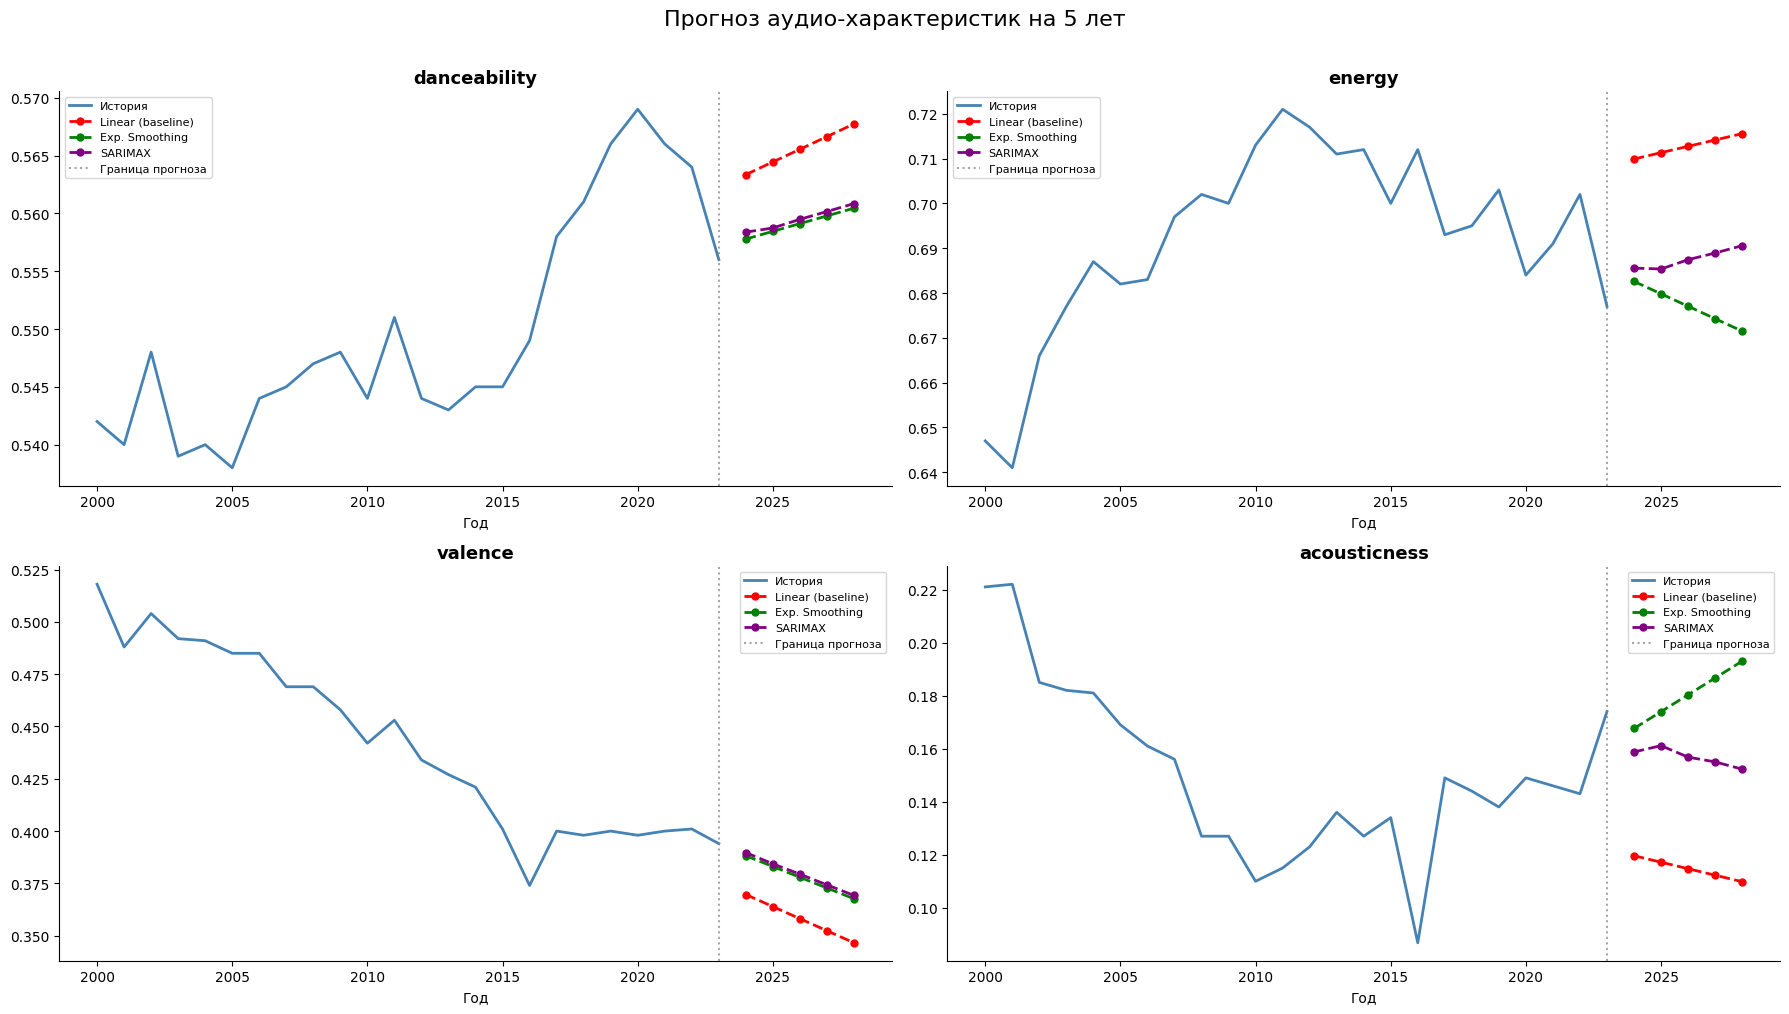

In [12]:
yearly_indexed = yearly.set_index('year')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

colors = {'linear': 'red', 'exp_smoothing': 'green', 'sarimax': 'purple'}
labels = {'linear': 'Linear (baseline)', 'exp_smoothing': 'Exp. Smoothing', 'sarimax': 'SARIMAX'}

for i, feat in enumerate(FEATURES_TO_FORECAST):
    ax = axes[i]
    series = yearly_indexed[feat].dropna()
    
    # Исторические данные
    ax.plot(series.index, series.values, color='steelblue', linewidth=2, label='История')
    
    # Прогнозы
    forecasts = forecast_feature(series, n_forecast=FORECAST_YEARS)
    future = forecasts['future_years']
    
    for method in ['linear', 'exp_smoothing', 'sarimax']:
        if forecasts[method] is not None:
            ax.plot(
                future, forecasts[method],
                '--', color=colors[method],
                linewidth=2, label=labels[method], marker='o', markersize=5
            )
    
    # Разделитель история / прогноз
    ax.axvline(x=series.index[-1], color='gray', linestyle=':', alpha=0.7, label='Граница прогноза')
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel('Год')
    ax.legend(fontsize=8)

plt.suptitle(f'Прогноз аудио-характеристик на {FORECAST_YEARS} лет', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## Метрики 

In [13]:
TRAIN_UNTIL = 2018
TEST_YEARS = 5

results_rows = []

for feat in FEATURES_TO_FORECAST:
    series = yearly_indexed[feat].dropna()
    
    train = series[series.index <= TRAIN_UNTIL]
    test  = series[(series.index > TRAIN_UNTIL) & (series.index <= TRAIN_UNTIL + TEST_YEARS)]
    
    if len(test) == 0:
        continue
    
    forecasts = forecast_feature(train, n_forecast=len(test))
    y_true = test.values
    
    for method in ['linear', 'exp_smoothing', 'sarimax']:
        if forecasts[method] is not None:
            y_pred = forecasts[method]
            mae  = mean_absolute_error(y_true, y_pred)
            rmse = mean_squared_error(y_true, y_pred) ** 0.5
            results_rows.append({
                'feature': feat,
                'method': method,
                'MAE': round(mae, 4),
                'RMSE': round(rmse, 4),
            })

results_df = pd.DataFrame(results_rows)
results_pivot = results_df.pivot_table(index='feature', columns='method', values=['MAE', 'RMSE'])
print('Метрики качества прогноза (меньше = лучше):')
results_pivot.round(4)

Метрики качества прогноза (меньше = лучше):


MAE                          RMSE                
method       exp_smoothing  linear sarimax exp_smoothing  linear sarimax
feature                                                                 
acousticness        0.0071  0.0601  0.0196        0.0086  0.0628  0.0258
danceability        0.0097  0.0097  0.0048        0.0110  0.0110  0.0057
energy              0.0120  0.0370  0.0139        0.0149  0.0391  0.0171
valence             0.0304  0.0304  0.0210        0.0317  0.0317  0.0225

In [14]:
# Какой метод лучше в среднем по MAE?
best_by_mae = results_df.groupby('method')['MAE'].mean().sort_values()
print('Средний MAE по всем признакам:')
print(best_by_mae.round(4))
print(f'\nЛучший метод: {best_by_mae.idxmin()}')

Средний MAE по всем признакам:
method
exp_smoothing    0.0148
sarimax          0.0148
linear           0.0343
Name: MAE, dtype: float64

Лучший метод: exp_smoothing


## Прогноз популярности жанров

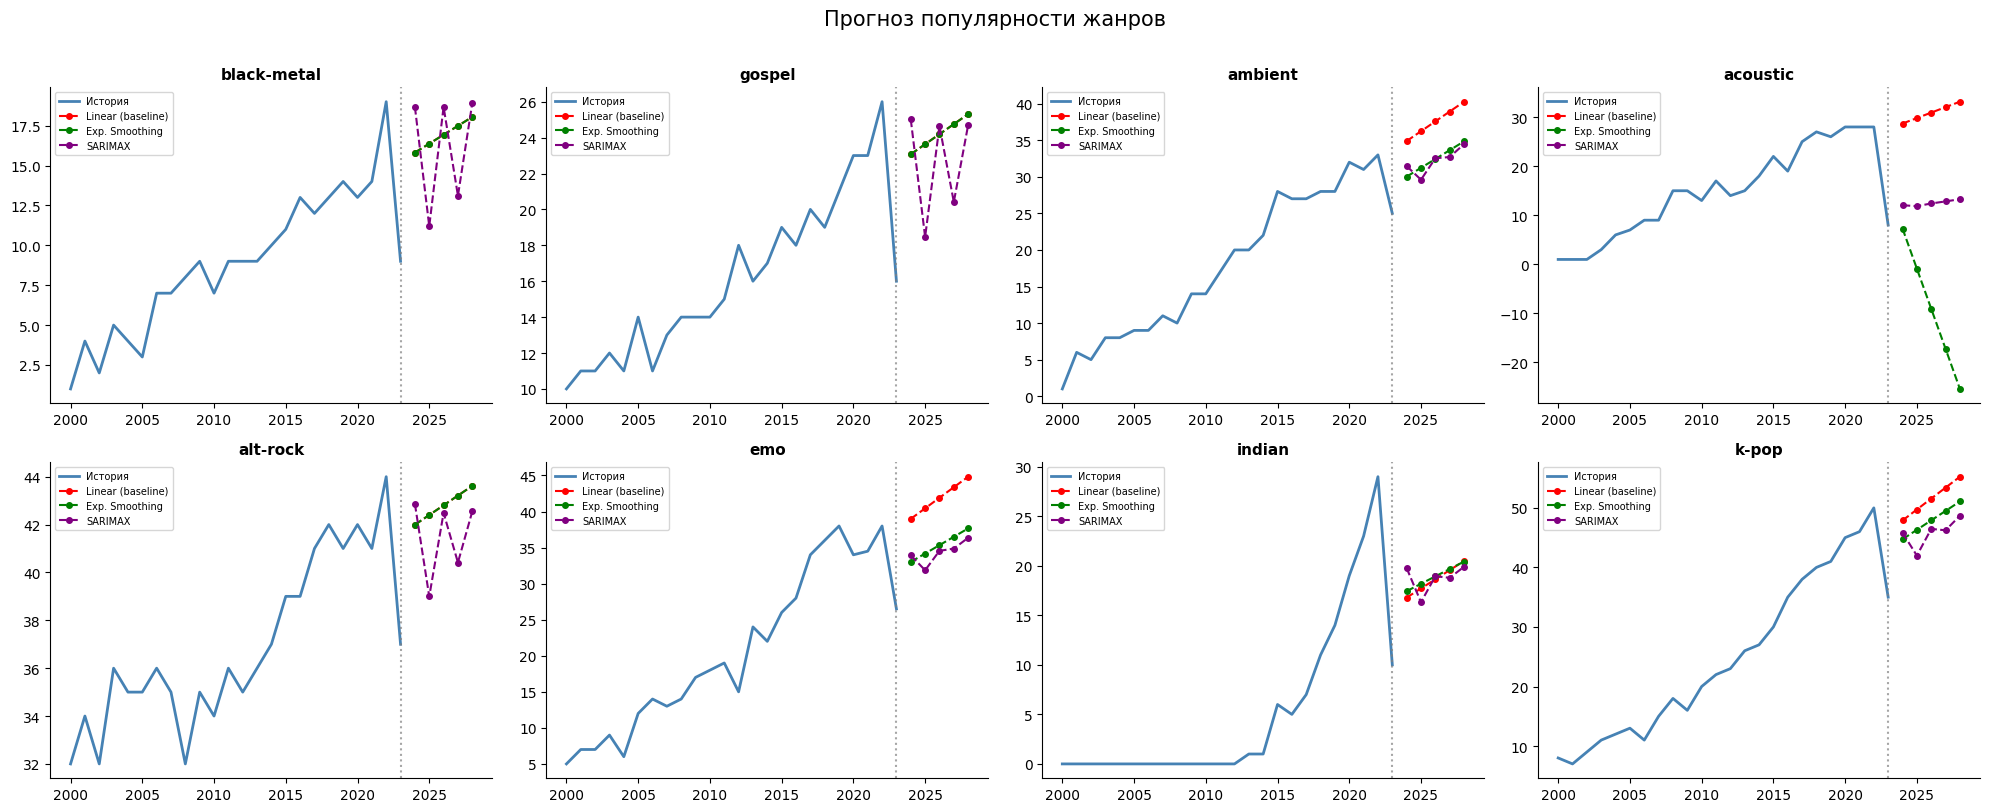

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, genre in enumerate(top_genres[:8]):
    ax = axes[i]
    genre_data = genre_year[genre_year['genre'] == genre].set_index('year')['popularity']
    
    if len(genre_data) < 10:
        ax.set_title(f'{genre} (мало данных)')
        continue
    
    ax.plot(genre_data.index, genre_data.values, color='steelblue', linewidth=2, label='История')
    
    forecasts = forecast_feature(genre_data, n_forecast=FORECAST_YEARS)
    future = forecasts['future_years']
    
    for method, color in colors.items():
        if forecasts[method] is not None:
            ax.plot(future, forecasts[method], '--', color=color, linewidth=1.5,
                    label=labels[method], marker='o', markersize=4)
    
    ax.axvline(x=genre_data.index[-1], color='gray', linestyle=':', alpha=0.7)
    ax.set_title(genre, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Прогноз популярности жанров', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('genre_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## Бизнес-выводы

На основе анализа трендов можно сделать следующие выводы для продуктовой стратегии:

**Что растёт:** `energy`, `danceability`, `loudness` — музыка становится более интенсивной и танцевальной. Платформа может усиливать рекомендации в этих направлениях.

**Что падает:** `acousticness`, `instrumentalness` — живые и инструментальные треки теряют долю. Артистам в этих жанрах стоит адаптировать продакшн.

**Прогноз жанров:** Жанры с растущим трендом популярности — приоритет для контрактов и продвижения. Жанры с падающим — риск для инвестиций.

**Ограничения модели:** Прогнозы на 5 лет имеют высокую неопределённость — используем как индикатор направления, не точного значения.